[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notebooks/learning-guides/02-separando-los-datos.ipynb)


# 🤖 Machine Learning — Separando los Datos

**Notebook 2 de 2 · Compatible con Google Colab**

Este notebook reproduce y amplía las diapositivas **“Separando los Datos”**.

## Objetivos

Al finalizar podrás:

1. Comprender **underfitting** y **overfitting**.
2. Diferenciar datos de entrenamiento y datos de prueba.
3. Separar `X` y `y`.
4. Aplicar `train_test_split`.
5. Interpretar `X_train`, `X_test`, `y_train` y `y_test`.
6. Comprender el papel de `test_size` y `random_state`.
7. Conocer `stratify`, validación y buenas prácticas para evitar *data leakage*.



## 1. Underfitting y Overfitting

### Underfitting
Ocurre cuando el modelo es **demasiado simple** para capturar la estructura real de los datos. El desempeño es deficiente tanto en entrenamiento como en datos nuevos.

### Overfitting
Ocurre cuando el modelo se ajusta demasiado a los ejemplos de entrenamiento, incluyendo ruido y particularidades. Puede rendir muy bien en entrenamiento, pero mal con datos nuevos.

Una analogía útil es un estudiante que **memoriza** las respuestas de un examen de práctica, pero no aprende el concepto.



## 2. ¿Por qué dividir los datos?

Las diapositivas distinguen dos roles:

### Datos de entrenamiento
- Normalmente representan aproximadamente **70–80%** de los datos.
- El modelo aprende patrones y ajusta sus parámetros con ellos.

### Datos de prueba
- Normalmente representan aproximadamente **20–30%**.
- El modelo **no debe verlos durante el entrenamiento**.
- Se usan para medir qué tan bien generaliza a datos nuevos.

### Tres funciones clave

1. Obtener una evaluación más realista.
2. Detectar sobreajuste.
3. Evaluar la capacidad de generalización.


## 3. Importar librerías

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar o reconstruir el conjunto preparado

Si ejecutaste el Notebook 1 y subiste `DATOS1_CODIFICADO.csv`, se puede leer directamente.

Para que este Notebook 2 también funcione de forma independiente, si el archivo no existe reconstruiremos exactamente el conjunto de datos de las diapositivas.


In [ ]:

from pathlib import Path

archivo = Path("DATOS1_CODIFICADO.csv")

if archivo.exists():
    df_codificado = pd.read_csv(archivo)
    print("✅ Se cargó DATOS1_CODIFICADO.csv")
else:
    print("ℹ️ No se encontró el CSV. Se reconstruirá el conjunto de las diapositivas.")

    datos = {
        "pais": [
            "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
            "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
            "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA"
        ],
        "edad": [
            37, 45, 28, 23,
            56, 34, 25, np.nan,
            14, 18, np.nan, 19
        ],
        "salario": [
            800000, 900000, 300000, 400000,
            200000, np.nan, 500000, 600000,
            300000, 200000, 700000, 450000
        ],
        "compro": [
            "SI", "SI", "SI", "NO",
            "NO", "NO", "NO", "SI",
            "SI", "SI", "SI", "NO"
        ]
    }

    df = pd.DataFrame(datos)

    X_aux = df.iloc[:, :-1].values
    y_aux = df.iloc[:, -1].values

    imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
    X_aux[:, 1:3] = imputer.fit_transform(X_aux[:, 1:3])

    df_limpio = pd.DataFrame(X_aux, columns=["pais", "edad", "salario"])
    df_limpio["edad"] = pd.to_numeric(df_limpio["edad"])
    df_limpio["salario"] = pd.to_numeric(df_limpio["salario"])
    df_limpio["compro"] = y_aux

    df_codificado = pd.get_dummies(
        df_limpio,
        columns=["pais", "compro"],
        drop_first=True
    )

    for col in df_codificado.columns:
        if df_codificado[col].dtype == "bool":
            df_codificado[col] = df_codificado[col].astype(int)

    columnas_pais = [c for c in df_codificado.columns if c.startswith("pais_")]
    df_codificado = df_codificado[
        columnas_pais + ["edad", "salario", "compro_SI"]
    ]

display(df_codificado)


ℹ️ No se encontró el CSV. Se reconstruirá el conjunto de las diapositivas.


,pais_COLOMBIA,pais_ECUADOR,pais_PERU,edad,salario,compro_SI
0,1,0,0,37.0,800000.000000,1
1,0,0,1,45.0,900000.000000,1
2,0,1,0,28.0,300000.000000,1
3,0,0,0,23.0,400000.000000,0
4,1,0,0,56.0,200000.000000,0
5,0,0,1,34.0,486363.636364,0
6,0,1,0,25.0,500000.000000,0
7,0,0,0,29.9,600000.000000,1
8,1,0,0,14.0,300000.000000,1
9,0,0,1,18.0,200000.000000,1



## 5. Definir `X` y `y`

Como en las diapositivas:

- Todas las columnas excepto la última serán `X`.
- La última columna (`compro_SI`) será `y`.


In [ ]:

X = df_codificado.iloc[:, :-1].values
y = df_codificado.iloc[:, -1].values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nX:")
print(X)

print("\ny:")
print(y)


Forma de X: (12, 5)
Forma de y: (12,)

X:
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 3.70000000e+01
  8.00000000e+05]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 4.50000000e+01
  9.00000000e+05]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 2.80000000e+01
  3.00000000e+05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.30000000e+01
  4.00000000e+05]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 5.60000000e+01
  2.00000000e+05]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 3.40000000e+01
  4.86363636e+05]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 2.50000000e+01
  5.00000000e+05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.99000000e+01
  6.00000000e+05]
 [1.00000000e+00 0.00000000e+00 0.00000000e+00 1.40000000e+01
  3.00000000e+05]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 1.80000000e+01
  2.00000000e+05]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 2.99000000e+01
  7.00000000e+05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.90000000e+01
  4.50000000e+05


## 6. Separar entrenamiento y prueba

Las diapositivas utilizan:

```python
train_test_split(X, y, test_size=0.2, random_state=0)
```

- `test_size=0.2`: aproximadamente 20% de observaciones para prueba.
- `random_state=0`: hace reproducible la selección aleatoria.


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (9, 5)
X_test : (3, 5)
y_train: (9,)
y_test : (3,)


## 7. Mostrar los cuatro conjuntos

In [ ]:

columnas_X = list(df_codificado.columns[:-1])

print("X_train")
display(pd.DataFrame(X_train, columns=columnas_X))

print("X_test")
display(pd.DataFrame(X_test, columns=columnas_X))

print("y_train")
display(pd.Series(y_train, name="compro_SI").to_frame())

print("y_test")
display(pd.Series(y_test, name="compro_SI").to_frame())


X_train


,pais_COLOMBIA,pais_ECUADOR,pais_PERU,edad,salario
0,0.0,1.0,0.0,29.9,700000.000000
1,0.0,1.0,0.0,28.0,300000.000000
2,1.0,0.0,0.0,14.0,300000.000000
3,0.0,0.0,1.0,45.0,900000.000000
4,0.0,0.0,0.0,29.9,600000.000000
5,0.0,0.0,1.0,18.0,200000.000000
6,0.0,0.0,0.0,23.0,400000.000000
7,1.0,0.0,0.0,37.0,800000.000000
8,0.0,0.0,1.0,34.0,486363.636364


X_test


,pais_COLOMBIA,pais_ECUADOR,pais_PERU,edad,salario
0,0.0,1.0,0.0,25.0,500000.0
1,0.0,0.0,0.0,19.0,450000.0
2,1.0,0.0,0.0,56.0,200000.0


y_train


,compro_SI
0,1
1,1
2,1
3,1
4,1
5,1
6,0
7,1
8,0


y_test


,compro_SI
0,0
1,0
2,0



Con `random_state=0`, el resultado reproduce el patrón mostrado en las diapositivas: 9 observaciones en entrenamiento y 3 en prueba.


## 8. Verificar proporciones

In [ ]:

n_total = len(y)
n_train = len(y_train)
n_test = len(y_test)

print(f"Total         : {n_total}")
print(f"Entrenamiento : {n_train} ({n_train/n_total:.1%})")
print(f"Prueba        : {n_test} ({n_test/n_total:.1%})")


Total         : 12
Entrenamiento : 9 (75.0%)
Prueba        : 3 (25.0%)



> Con solo 12 observaciones, `test_size=0.2` no puede dar exactamente 2.4 filas. `train_test_split` termina utilizando 3 filas para prueba, es decir, **25%** del total.


## 9. Distribución de la variable objetivo

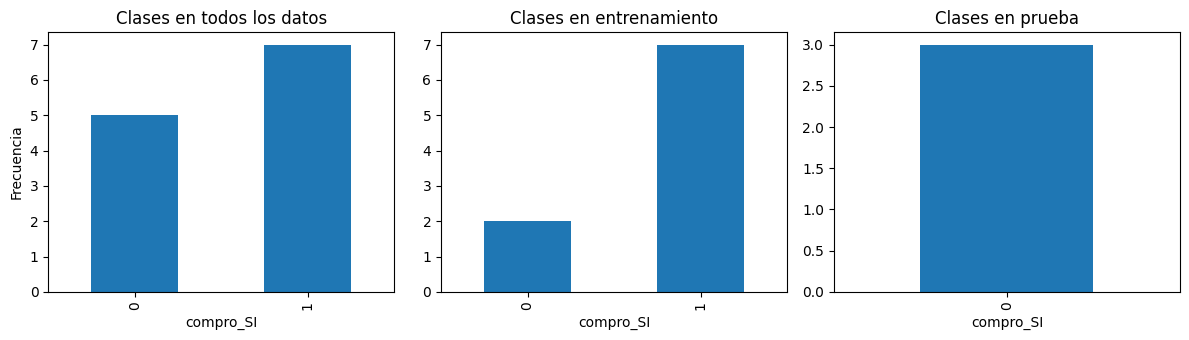

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

pd.Series(y, name="Total").value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Clases en todos los datos")
axes[0].set_xlabel("compro_SI")
axes[0].set_ylabel("Frecuencia")

pd.Series(y_train, name="Train").value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Clases en entrenamiento")
axes[1].set_xlabel("compro_SI")

pd.Series(y_test, name="Test").value_counts().sort_index().plot(kind="bar", ax=axes[2])
axes[2].set_title("Clases en prueba")
axes[2].set_xlabel("compro_SI")

plt.tight_layout()
plt.show()



### Observación importante

Con este conjunto pequeño y `random_state=0`, las 3 observaciones de prueba pertenecen a la clase `0` (`NO`).

Esto **no es un error de Python**. Es una consecuencia de hacer una división aleatoria con muy pocos datos.

En clasificación suele ser útil usar `stratify=y` para intentar conservar la proporción de clases.


## 10. División estratificada — contenido adicional

In [ ]:

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Distribución original:")
print(pd.Series(y).value_counts().sort_index())

print("\nDistribución entrenamiento estratificado:")
print(pd.Series(y_train_s).value_counts().sort_index())

print("\nDistribución prueba estratificada:")
print(pd.Series(y_test_s).value_counts().sort_index())


Distribución original:
0    5
1    7
Name: count, dtype: int64

Distribución entrenamiento estratificado:
0    4
1    5
Name: count, dtype: int64

Distribución prueba estratificada:
0    1
1    2
Name: count, dtype: int64



`stratify=y` es especialmente útil cuando:

- Hay clases desbalanceadas.
- El conjunto es pequeño.
- Queremos que entrenamiento y prueba tengan una composición de clases más parecida al conjunto original.


## 11. ¿Qué hace `random_state`?

In [ ]:

resultados = []

for semilla in [0, 1, 2, 10, 42]:
    _, X_te, _, y_te = train_test_split(
        X, y, test_size=0.25, random_state=semilla
    )

    resultados.append({
        "random_state": semilla,
        "n_test": len(y_te),
        "NO (0)": int((y_te == 0).sum()),
        "SI (1)": int((y_te == 1).sum())
    })

display(pd.DataFrame(resultados))


,random_state,n_test,NO (0),SI (1)
0,0,3,3,0
1,1,3,2,1
2,2,3,2,1
3,10,3,1,2
4,42,3,0,3



Cambiar `random_state` cambia **qué observaciones** llegan a entrenamiento y prueba.

Por eso, cuando se comparan experimentos, conviene fijar una semilla para obtener resultados reproducibles.



# ⭐ Contenido adicional recomendado

## 12. Flujo correcto para evitar *data leakage*

En un proyecto real, las transformaciones que **aprenden parámetros** de los datos (por ejemplo, la media de una imputación o los parámetros de un escalador) deberían ajustarse **solo con el conjunto de entrenamiento**.

La secuencia recomendada es:

**Datos crudos → train/test split → fit del preprocesamiento en train → transform de train/test → entrenamiento del modelo**


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Datos originales, antes de imputar/codificar
datos_raw = pd.DataFrame({
    "PAIS": [
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA"
    ],
    "EDAD": [37,45,28,23,56,34,25,np.nan,14,18,np.nan,19],
    "SALARIO": [
        800000,900000,300000,400000,200000,np.nan,
        500000,600000,300000,200000,700000,450000
    ],
    "COMPRO": ["SI","SI","SI","NO","NO","NO","NO","SI","SI","SI","SI","NO"]
})

X_raw = datos_raw[["PAIS", "EDAD", "SALARIO"]]
y_raw = datos_raw["COMPRO"].map({"NO": 0, "SI": 1})

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.25,
    random_state=0,
    stratify=y_raw
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler())
            ]),
            ["EDAD", "SALARIO"]
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            ["PAIS"]
        )
    ]
)

modelo = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("clasificador", LogisticRegression())
])

modelo.fit(X_train_raw, y_train_raw)
pred = modelo.predict(X_test_raw)

print("Accuracy:", accuracy_score(y_test_raw, pred))
print("\nReporte de clasificación:")
print(classification_report(y_test_raw, pred, zero_division=0))


Accuracy: 0.6666666666666666

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3




> **Importante:** el conjunto tiene solo 12 filas. La métrica anterior sirve para aprender el flujo de trabajo, pero no para sacar conclusiones sólidas sobre desempeño real.



## 13. Demostración breve de Underfitting vs Overfitting

Usaremos un conjunto sintético más grande para ver la idea de manera clara con árboles de decisión:

- Árbol muy poco profundo → puede producir **underfitting**.
- Profundidad intermedia → suele equilibrar ajuste y generalización.
- Árbol sin límite → puede producir **overfitting**.


In [ ]:

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X_demo, y_demo = make_moons(n_samples=500, noise=0.30, random_state=42)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_demo, y_demo, test_size=0.30, random_state=42, stratify=y_demo
)

comparacion = []

for profundidad in [1, 4, None]:
    arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    arbol.fit(Xd_train, yd_train)

    acc_train = arbol.score(Xd_train, yd_train)
    acc_test = arbol.score(Xd_test, yd_test)

    comparacion.append({
        "max_depth": str(profundidad),
        "accuracy_train": round(acc_train, 3),
        "accuracy_test": round(acc_test, 3),
        "brecha_train_test": round(acc_train - acc_test, 3)
    })

display(pd.DataFrame(comparacion))


,max_depth,accuracy_train,accuracy_test,brecha_train_test
0,1,0.831,0.793,0.038
1,4,0.906,0.880,0.026
2,None,1.000,0.867,0.133



### Cómo interpretarlo

- **Train bajo + Test bajo** → posible underfitting.
- **Train muy alto + Test claramente menor** → posible overfitting.
- **Train y Test buenos y cercanos** → mejor capacidad de generalización.

La diferencia entre entrenamiento y prueba es una señal útil, aunque siempre debe interpretarse junto con el contexto, el tamaño del conjunto y las métricas apropiadas.



## 14. Validación y Cross-Validation

En proyectos reales puede ser útil tener:

- **Train**: aprender parámetros del modelo.
- **Validation**: elegir hiperparámetros.
- **Test**: evaluación final.

Cuando hay pocos datos, también se usa **K-Fold Cross-Validation**, que evalúa el modelo varias veces usando distintas particiones.

Con un conjunto de solo 12 filas, una única división puede ser muy inestable.


In [ ]:

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for fold, (idx_train, idx_val) in enumerate(cv.split(X, y), start=1):
    print(
        f"Fold {fold}: "
        f"train={len(idx_train)} observaciones, "
        f"validación={len(idx_val)} observaciones"
    )


Fold 1: train=8 observaciones, validación=4 observaciones
Fold 2: train=8 observaciones, validación=4 observaciones
Fold 3: train=8 observaciones, validación=4 observaciones



## 15. Mini ejercicios

1. Cambia `test_size` a `0.30`. ¿Cuántas filas quedan en prueba?
2. Prueba diferentes valores de `random_state`.
3. Compara una división normal con una división usando `stratify=y`.
4. Explica con tus palabras:
   - underfitting
   - overfitting
   - generalización
5. ¿Por qué no se debe evaluar el modelo únicamente con los datos de entrenamiento?
6. ¿Por qué el conjunto de prueba debería mantenerse “oculto” hasta la evaluación final?



## ✅ Resumen

El flujo principal de este notebook fue:

**Datos preparados → X/y → train/test split → inspección de particiones → análisis de generalización**

Además, añadimos:

- División estratificada.
- Efecto de `random_state`.
- Pipeline sin *data leakage*.
- Ejemplo práctico de underfitting/overfitting.
- Introducción a Cross-Validation.

Con estos dos notebooks ya tienes una base mucho más completa para continuar con el entrenamiento de modelos supervisados.
